<a href="https://colab.research.google.com/github/manu93jadon/CI-CD-Project/blob/master/CO2_Emission_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries and Initial Setup

In [ ]:
import requests

url = "https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/158/208/original/CO2_Emissions.csv?1760012266"
filename = "CO2_Emissions.csv"

response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors

with open(filename, 'wb') as f:
    f.write(response.content)

print(f"Dataset downloaded successfully to {filename}")

Dataset downloaded successfully to CO2_Emissions.csv


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# 1 ) Begin by familiarizing yourself with the dataset. Identify what kind of information is captured about vehicles and how these variables might influence CO₂ emissions.

In [ ]:
emission_training_ds = pd.read_csv(filename)

In [ ]:
emission_training_ds.info() #Check the info for nulls

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

##Conclusion :


*   **No Nulls** are observed
*   **Multiple Fuel Consumption** metrics are provided, might be reduntant information for our model training


*   CO2 emission, the target variable is int64, we would require a **Regression Model**.
*   **Categorial Data** - 'Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type'


*  **Numerical Columns** - Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km) ,Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)             

*   The components which we expect to have more telling impact on CO2 emissions are Engine Size and Type, Fuel Type and Vehicle Class
*   Tranmission Type might not really have very big impact on CO2 emission



#2)Examine the dataset for any inconsistencies, missing entries, or data quality issues. Consider what preprocessing steps may be necessary to make the dataset ready for meaningful analysis.

### Data Quality Check

#### Check for unique values for every column

In [ ]:
emission_training_ds.nunique()

,0
Make,42
Model,2053
Vehicle Class,16
Engine Size(L),51
Cylinders,8
Transmission,27
Fuel Type,5
Fuel Consumption City (L/100 km),211
Fuel Consumption Hwy (L/100 km),143
Fuel Consumption Comb (L/100 km),181


##### Observation - Very High Cardinality in training data for "Model", one hot encoding would create a very large dataset and might not be really useful in calculating CO2 emission, let us check if we can reduce cardinality by grouping them for
is_4WD - 4WD|4X4|AWD
is_FFV - FFV
SWB = Short wheelbase
LWB = Long wheelbase
EWB = Extended wheelbase
if nothing is present then mark them as Standard to avoid nulls.

#### Check for Value Counts for every categorical column

In [ ]:
categorical_cols = ['Make','Vehicle Class', 'Transmission', 'Fuel Type']
for i in categorical_cols:
    print(f"--- {i} ---")
    print(emission_training_ds[i].value_counts())



--- Make ---
Make
FORD             628
CHEVROLET        588
BMW              527
MERCEDES-BENZ    419
PORSCHE          376
TOYOTA           330
GMC              328
AUDI             286
NISSAN           259
JEEP             251
DODGE            246
KIA              231
HONDA            214
HYUNDAI          210
MINI             204
VOLKSWAGEN       197
MAZDA            180
LEXUS            178
JAGUAR           160
CADILLAC         158
SUBARU           140
VOLVO            124
INFINITI         108
BUICK            103
RAM               97
LINCOLN           96
MITSUBISHI        95
CHRYSLER          88
LAND ROVER        85
FIAT              73
ACURA             72
MASERATI          61
ROLLS-ROYCE       50
ASTON MARTIN      47
BENTLEY           46
LAMBORGHINI       41
ALFA ROMEO        30
GENESIS           25
SCION             22
SMART              7
BUGATTI            3
SRT                2
Name: count, dtype: int64
--- Vehicle Class ---
Vehicle Class
SUV - SMALL                 1217
MID-S

##### Observation - Fuel Type 'N' is just 1, can be dropped

#### Plot histplot and Boxplot to better understand our Data and Outliers

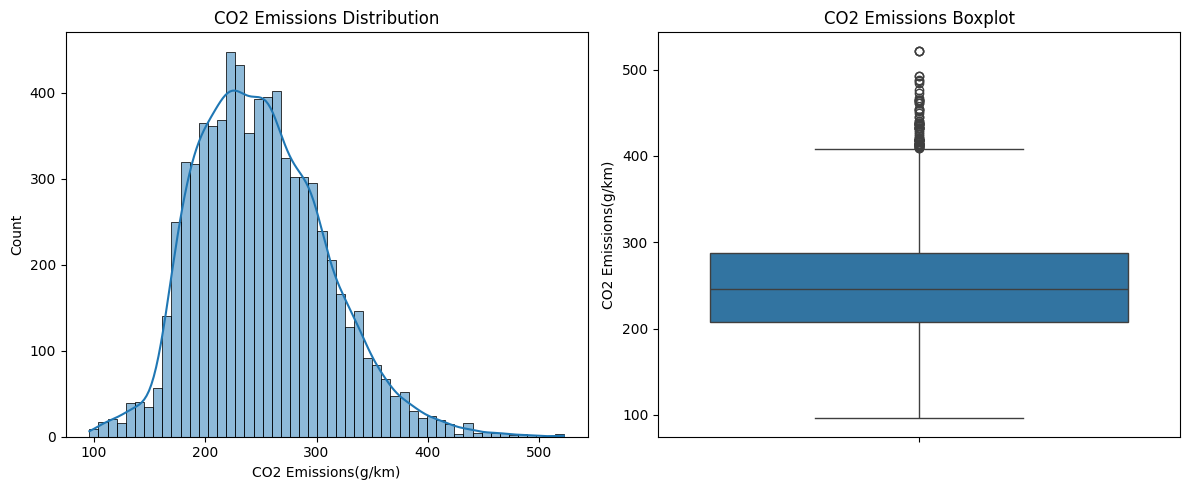

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(emission_training_ds["CO2 Emissions(g/km)"], kde=True)
plt.title("CO2 Emissions Distribution")

plt.subplot(1, 2, 2)
sns.boxplot(y=emission_training_ds["CO2 Emissions(g/km)"])
plt.title("CO2 Emissions Boxplot")

plt.tight_layout()
plt.show()

##### Observation -
Not Ideally Normal, bit more long tail on right side, 200 - 270 is where most vehicles lie. Right tail could be due to heavy vehicle or sports cars.
Boxplot shows high outliers for >400.

Linear Regression might fit our requirement here as normal distribution shape holds well. We will check for Assumptions of Normal Distribution

### Dataset Cleanup

In [ ]:
#Extract information about wheelbase, flex fuel, and if AWD or 4WD
emission_training_ds_cleaned = emission_training_ds.copy()
emission_training_ds_cleaned["is_FFV"]=emission_training_ds["Model"].str.contains("FFV",case=False).astype(int) #If Vehicle is FFV

emission_training_ds_cleaned["is_4WD"]=emission_training_ds["Model"].str.contains("4WD|4X4|AWD", regex=True, case=False).astype(int) # If Vehicle is AWD|4WD|4x4
def extract_wheelbase(model_from_ds):
  model_str = str(model_from_ds).upper()
  if "SWB" in model_str:
    return "SWB"
  elif "LWB" in model_str:
    return "LWB"
  elif "EWB" in model_str:
    return "EWB"
  return "Standard"
emission_training_ds_cleaned["Wheelbase"]=emission_training_ds['Model'].apply(extract_wheelbase)
#Dropping 'Model'
emission_training_ds_cleaned=emission_training_ds_cleaned.drop('Model',axis=1)
#Dropping 'N' fuel type
emission_training_ds_cleaned = emission_training_ds_cleaned[emission_training_ds_cleaned['Fuel Type'] != 'N']
print("Info of the Cleaned Dataset")
emission_training_ds_cleaned.info()
print("Wheelbase value count")
print(emission_training_ds_cleaned['Wheelbase'].value_counts())
print("FFV value count")
print(emission_training_ds_cleaned['is_FFV'].value_counts())
print("4WD value count")
print(emission_training_ds_cleaned['is_4WD'].value_counts())
print("Shape of Cleaned Dataset")
emission_training_ds_cleaned.shape



Info of the Cleaned Dataset
<class 'pandas.core.frame.DataFrame'>
Index: 7384 entries, 0 to 7384
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7384 non-null   object 
 1   Vehicle Class                     7384 non-null   object 
 2   Engine Size(L)                    7384 non-null   float64
 3   Cylinders                         7384 non-null   int64  
 4   Transmission                      7384 non-null   object 
 5   Fuel Type                         7384 non-null   object 
 6   Fuel Consumption City (L/100 km)  7384 non-null   float64
 7   Fuel Consumption Hwy (L/100 km)   7384 non-null   float64
 8   Fuel Consumption Comb (L/100 km)  7384 non-null   float64
 9   Fuel Consumption Comb (mpg)       7384 non-null   int64  
 10  CO2 Emissions(g/km)               7384 non-null   int64  
 11  is_FFV                            7384 non-nul

(7384, 14)

####Observation - Now we have removed high cardinality of "Model" Column, broken it into Fewer Categorical Options Data. Though Wheelbase categories other than "Standard" are really few

#3 ) Study the relationships between various vehicle features and CO₂ emissions. Which attributes appear to have stronger influence on emission levels? Use suitable methods to support your reasoning.

## Plotting for Correlation Matrix and Heatmap

Text(0.5, 1.0, 'Correlation Matrix')

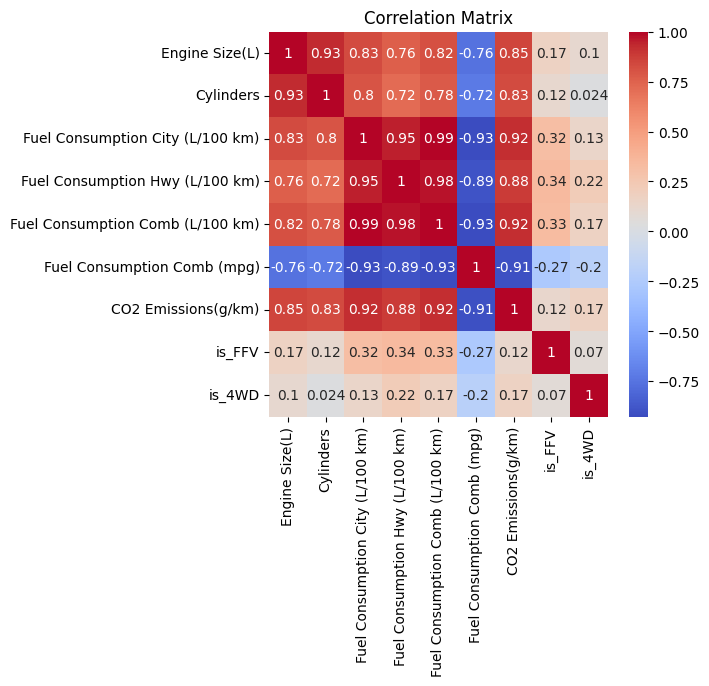

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(emission_training_ds_cleaned.corr(numeric_only=True),annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")

##Observation -


1.   Very Evident that Multiple Fuel Consumption Parameters - Fuel Consumption City and Fuel Consumption Comb show very **high correlation** with each other
2.   Mathematical inverse - Fuel Consumption Comb(mpg) - Shows **inverse correlation** with rest of FC Metrices.
3. Engine Size, Fuel Consumption HWY and Fuel Consumption City/Comb have very big **influence on CO2 Emissions**





#4 ) Create visual summaries that reveal how emission levels change with respect to different numerical variables in the dataset. Focus on uncovering patterns or trends that might not be immediately visible.

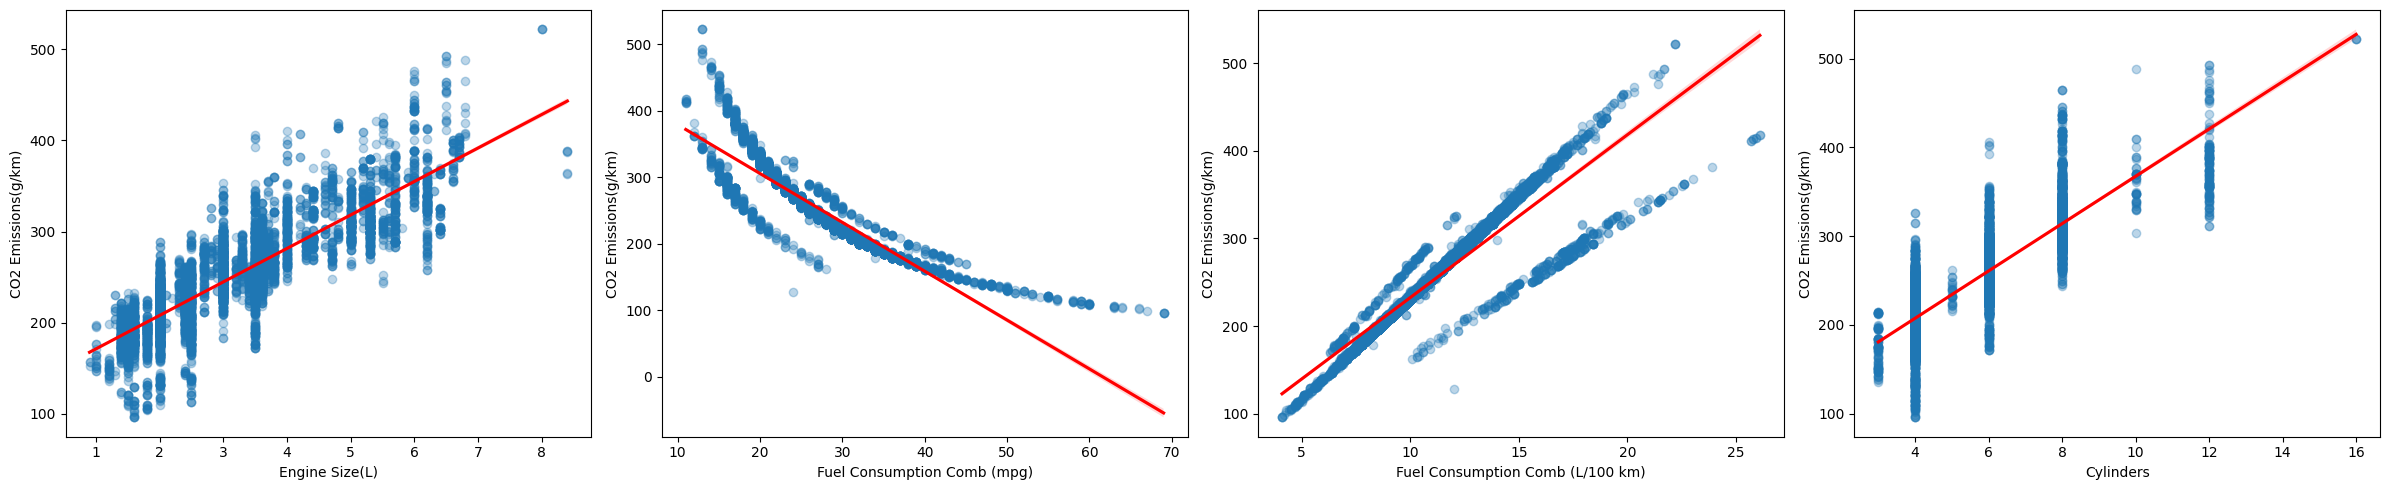

In [ ]:
#We will use RegPlot to check Regression Trendline
plt.figure(figsize=(24, 5))
# Plot 1: Engine Size vs Emissions
plt.subplot(1, 4, 1)
sns.regplot(x='Engine Size(L)',y='CO2 Emissions(g/km)',data=emission_training_ds_cleaned,scatter_kws={"alpha": 0.3},line_kws={"color": "red"})
# Plot 2: Fuel Consumption Comb(mpg) vs Emissions
plt.subplot(1, 4, 2)
sns.regplot(x='Fuel Consumption Comb (mpg)',y='CO2 Emissions(g/km)',data=emission_training_ds_cleaned,scatter_kws={"alpha": 0.3},line_kws={"color": "red"})
# Plot 3: Fuel Consumption Comb (L/100 km) vs Emissions
plt.subplot(1, 4, 3)
sns.regplot(x='Fuel Consumption Comb (L/100 km)',y='CO2 Emissions(g/km)',data=emission_training_ds_cleaned,scatter_kws={"alpha": 0.3},line_kws={"color": "red"})
# Plot 4: Cylinders vs Emissions
plt.subplot(1, 4, 4)
sns.regplot(x='Cylinders',y='CO2 Emissions(g/km)',data=emission_training_ds_cleaned,scatter_kws={"alpha": 0.3},line_kws={"color": "red"})
plt.tight_layout()
plt.show()

##### Observation:



*   **Engine Size vs Emissions** : Graph shows Points are tightly laid out around linear trend line. Good candidate for line
*  **Fuel Consumption Comb(mpg) vs Emissions** : Graph shows trend points are not following the linear trend line, they are almost following 1/x curvature.

*   **Fuel Consumption Comb (L/100 km) vs Emissions:** On the other hand if we consider L/100 Km as Fuel Consupmtion metrics , we see better linear trend. So better metric for Linear Regression Model. Though there seems to be some split , three lines are observed with different slopes and intercept, could be due to multiple Fuel Types.


*   **Cylinders vs Emissions:** This too seems to follow linear trend, high number of Cylinder means more Emission but rather than continous points, we see vertical points assimlating together to form multiple lines , that is because of Discreet Values of Cylinders like 2,3, etc.









#5 ) Compare emission levels across different vehicle types or fuel categories. Identify any clear distinctions or surprising findings that emerge.

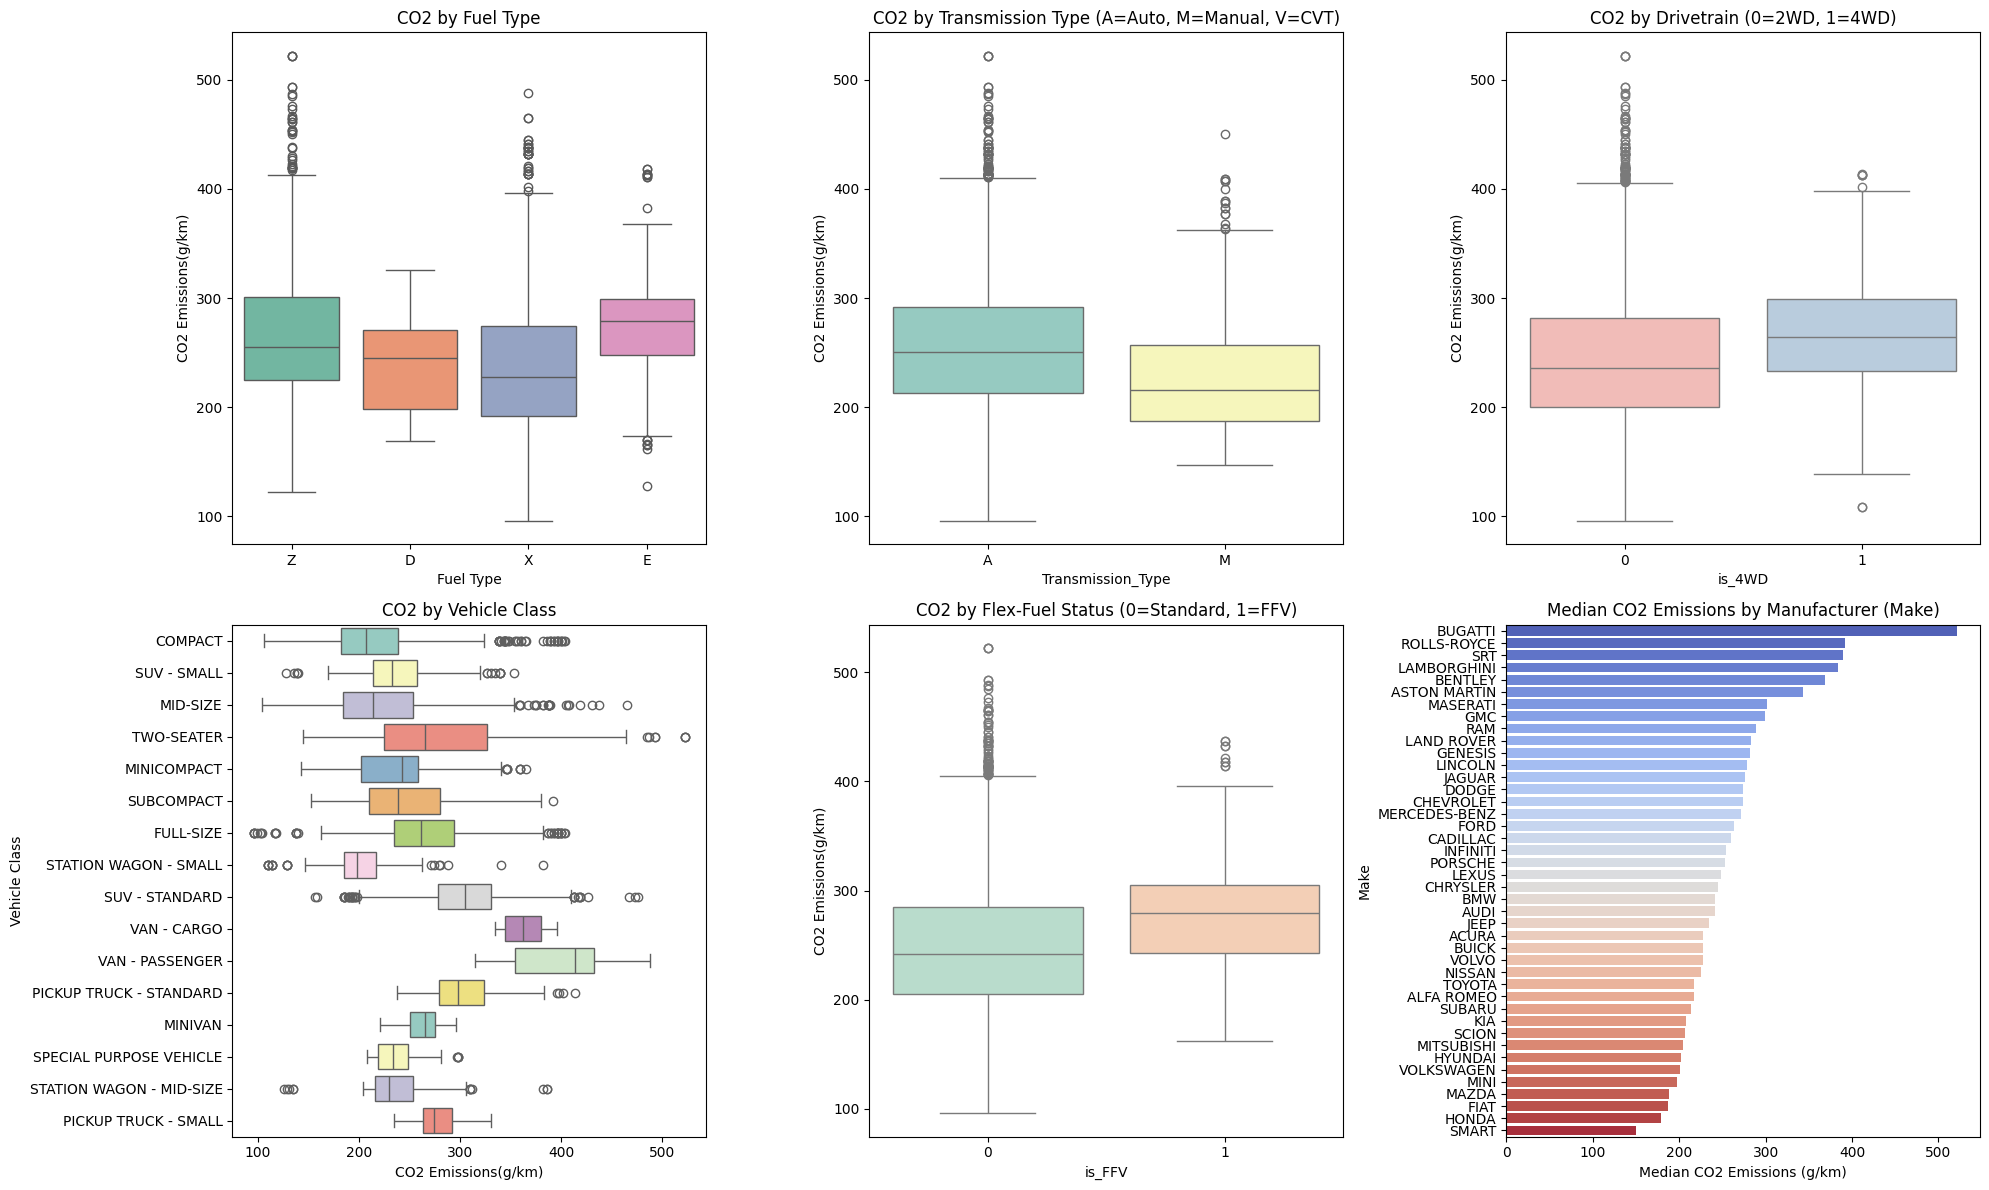

In [ ]:
#Categories to be considered :
#Fuel Type
#Vehicle Class
#Make- we will check avg of CO2 emissions per Make due to high cardinality
#Tranmission
#4WD or not
plt.figure(figsize=(20, 12))

# 1. CO2 Emissions by Fuel Type
plt.subplot(2, 3, 1)
sns.boxplot(data=emission_training_ds_cleaned,x="Fuel Type",y="CO2 Emissions(g/km)",hue="Fuel Type",palette="Set2",legend=False,)
plt.title("CO2 by Fuel Type")

# 2. CO2 Emissions by Transmission Type (Extract main type, e.g., A, M, AV)
emission_training_ds_cleaned["Transmission_Type"] = (emission_training_ds_cleaned["Transmission"].str[0])
plt.subplot(2, 3, 2)
sns.boxplot(data=emission_training_ds_cleaned,x="Transmission_Type",y="CO2 Emissions(g/km)",hue="Transmission_Type",palette="Set3",legend=False,)
plt.title("CO2 by Transmission Type (A=Auto, M=Manual, V=CVT)")

# 3. CO2 Emissions by Drivetrain (4WD vs 2WD)
plt.subplot(2, 3, 3)
sns.boxplot(data=emission_training_ds_cleaned,x="is_4WD",y="CO2 Emissions(g/km)",hue="is_4WD",palette="Pastel1",legend=False,)
plt.title("CO2 by Drivetrain (0=2WD, 1=4WD)")

# 4. CO2 Emissions by Vehicle Class
plt.subplot(2, 3, 4)
sns.boxplot(data=emission_training_ds_cleaned,x="CO2 Emissions(g/km)",y="Vehicle Class",hue="Vehicle Class",palette="Set3",legend=False,)
plt.title("CO2 by Vehicle Class")

# 5. CO2 Emissions by Flex-Fuel Status
plt.subplot(2, 3, 5)
sns.boxplot(data=emission_training_ds_cleaned,x="is_FFV",y="CO2 Emissions(g/km)",hue="is_FFV",palette="Pastel2",legend=False,)
plt.title("CO2 by Flex-Fuel Status (0=Standard, 1=FFV)")

# 6. Top/Bottom Average CO2 by Make (Bar Plot for High-Cardinality)
plt.subplot(2, 3, 6)
make_order = (emission_training_ds_cleaned.groupby("Make")["CO2 Emissions(g/km)"].median().sort_values(ascending=False))
sns.barplot(x=make_order.values,y=make_order.index,hue=make_order.index,palette="coolwarm",
legend=False,
)
plt.title("Median CO2 Emissions by Manufacturer (Make)")
plt.xlabel("Median CO2 Emissions (g/km)")

plt.tight_layout()
plt.show()

##Observations:
1) **Fuel Type** , Z(Premium Gasoline) and X have high outliers, fuel type paired with Vehicle Class might handle this. Though Diesel doesn't show any outlier, maybe it is used strictly by some Vehicle Classes only. *Surprisingly Ethanol shows more CO2 emission!*

2) **Transmission Type** A and M both show outliers, but Automatic seems to have more median emission levels than Manual.
3) **Drivetrain** - 2WD shows very high outliers hinting that some vehicle type having high emission levels also are in 2WD , yet 2WD vehicles show less median CO2 emissions.

3) **Vehicle Class** - VAN - PASSENGER, VAN - CARGO, and PICKUP TRUCK - STANDARD show high >300–350 g/km median. Conversely, COMPACT, SUBCOMPACT, and STATION WAGON - SMALL are around 200 g/km. *Suprisingly TWO-SEATER has an extremely wide spread range of emissions!*
4) **Flex-Fuel Status** - If vehicle is Flex Fuel enabled it shows less outliers and high median emissions. Makes sense as high end trucks have flex fuels and low emission daily use vehicles don't come in Flex Fuel Options.
5) **Make** As expected the Sports cars have very high CO2 emissions. Would be a good idea to have a column is_Sports "0/1" where 0 would mean mass market brands.

#6 ) Observe if there are any vehicles that produce unusually high or low emissions compared to others with similar characteristics. Reflect on what could explain such deviations.

## Strategy : To answer this question, let us try to group vehicles first with similar characteristics first.


1.   I will group vehicles as per their fuel consumption bucket, and I expect similar fuel consumption vehicles would show similar CO2 emissions.
2.   I will create one more group - by grouping together Engine Size(Small (≤ 2.0L),Medium (2.1L – 3.5L),and Large (> 3.5L) and Vehicle Class



#### Group 1

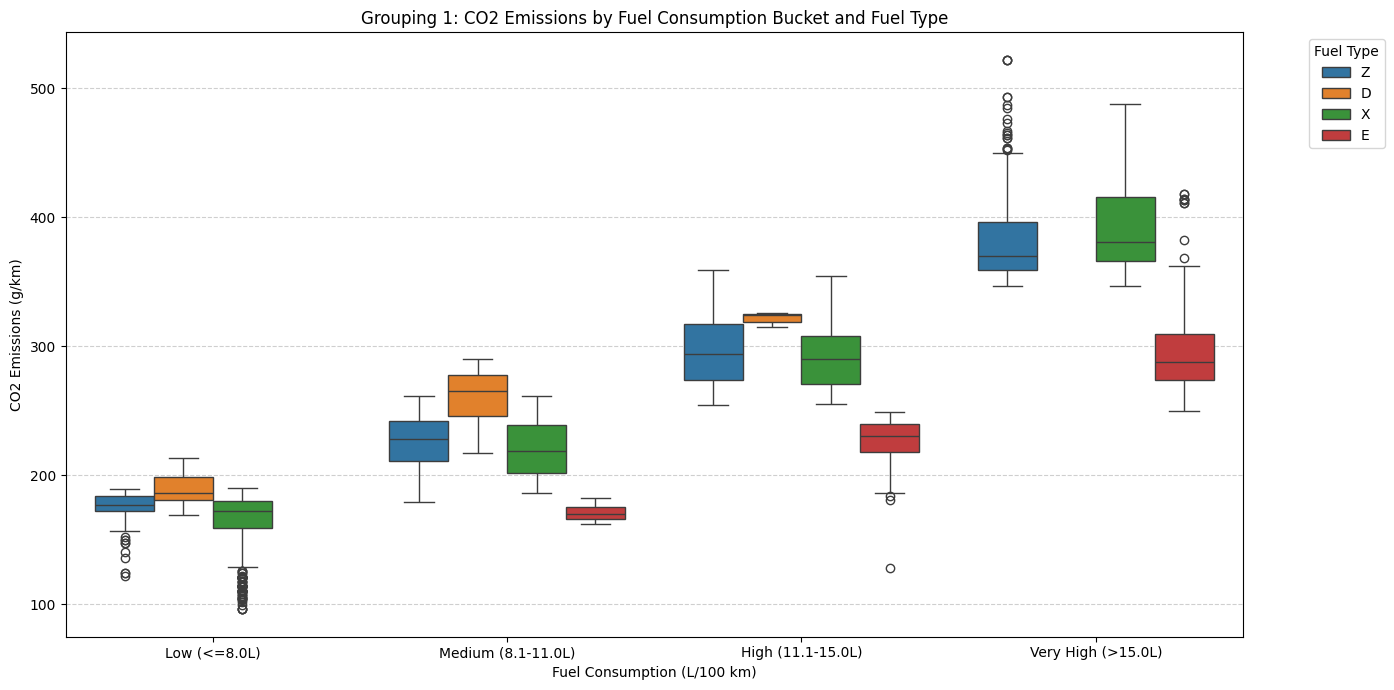

In [ ]:
#Group1 Group by Fuel Consumption

df = emission_training_ds_cleaned.copy()
#Calculate bins
consumption_bins = [0, 8.0, 11.0, 15.0, 30.0]
consumption_labels = ['Low (<=8.0L)', 'Medium (8.1-11.0L)', 'High (11.1-15.0L)', 'Very High (>15.0L)']

df['Consumption_Bucket'] = pd.cut(df['Fuel Consumption Comb (L/100 km)'], bins=consumption_bins, labels=consumption_labels,right=True)


plt.figure(figsize=(14, 7))
sns.boxplot(data=df,x='Consumption_Bucket',y='CO2 Emissions(g/km)',hue='Fuel Type',palette='tab10')
plt.title("Grouping 1: CO2 Emissions by Fuel Consumption Bucket and Fuel Type")
plt.xlabel("Fuel Consumption (L/100 km)")
plt.ylabel("CO2 Emissions (g/km)")
plt.legend(title="Fuel Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

######Group 1 Observation:


*   As per expectation **CO2 emissions are almost linearly increasing** with High Fuel Consumption
*   **Ethanol** consistently shows very **low median** emissions. A good fuel.
*   **Diesel** Consistently shows **high** median CO2 emissions in every FC class
*  **The "Very High (>15.0L)" bucket** shows extremely high outliers (reaching over 500 g/km) are driven by **high-performance/sports vehicles**.
*   **Low-Consumption Outliers**: Low outliers in efficient buckets (around 100 g/km) could be driven by advanced hybrid powertrains and alternative fuel options
*   **Possible Data Entry error** - One single low outlier on High Engine option for Ethanol around 120-130 seems hihgly unlikely







#### Group 2 As per Engine Capacity and Vehicle Class

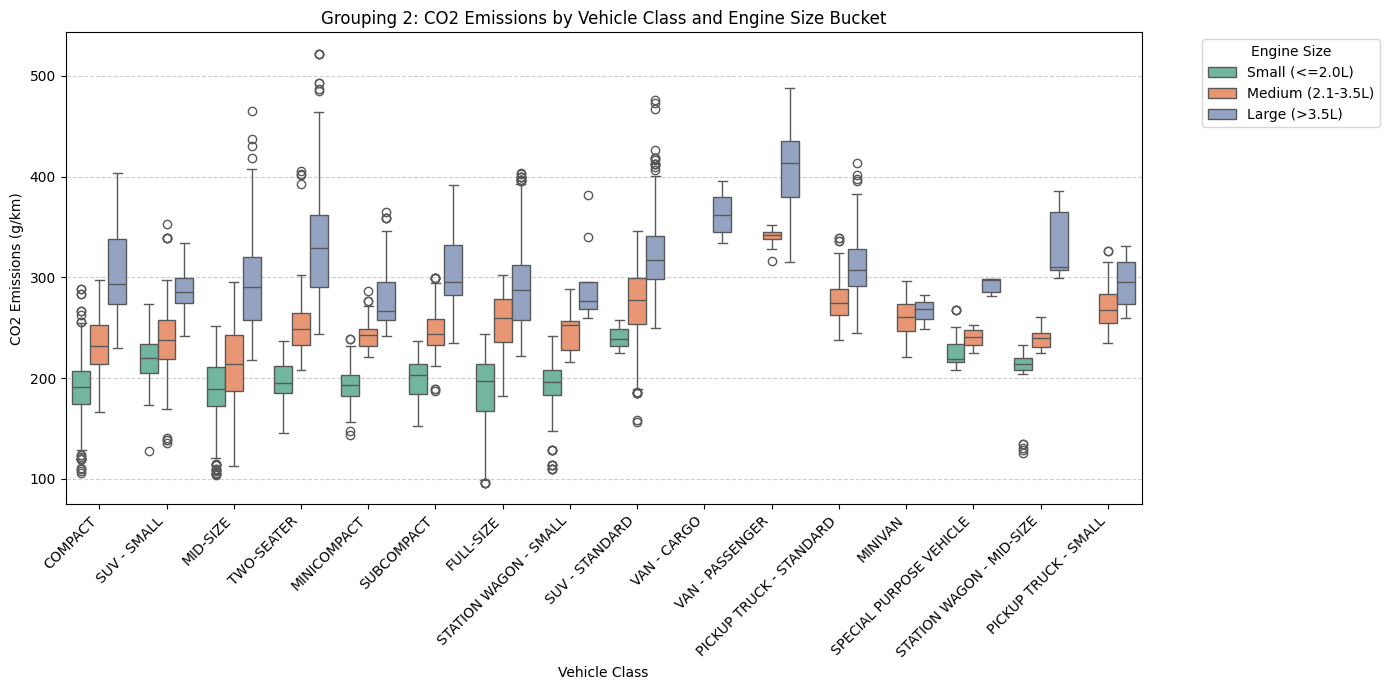

In [ ]:
df=emission_training_ds_cleaned.copy()
engine_bins=[0,2.0,3.5,10.0]
engine_labels=['Small (<=2.0L)', 'Medium (2.1-3.5L)', 'Large (>3.5L)']
df["Engine_Bucket"]=pd.cut(df["Engine Size(L)"],bins=engine_bins,labels=engine_labels,right=True)

#bar plot
plt.figure(figsize=(14, 7))
sns.boxplot(data=df,x='Vehicle Class',y='CO2 Emissions(g/km)',hue='Engine_Bucket',palette='Set2')
plt.title("Grouping 2: CO2 Emissions by Vehicle Class and Engine Size Bucket")
plt.xlabel("Vehicle Class")
plt.ylabel("CO2 Emissions (g/km)")
plt.xticks(rotation=45, ha='right') # Rotate labels so they don't overlap
plt.legend(title="Engine Size", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

######Group 2 Observation:



*   As expected, Higher Engine Capacity leads to high CO2 emission rates
*   TWO-SEATER and SUV - STANDARD - shows extremely high outliers , could be driven by Sports Variants
*   COMPACT, MID-SIZE - shows outliers dropping very low, as these vehicle comes in Ehtanol and other efficient fuel options
*   VAN - CARGO and PICKUP TRUCK - No options for Low Power Engines









# 7 ) Prepare the dataset for model building by ensuring that numerical and categorical features are appropriately represented. Consider any transformations or encodings that may improve interpretability.

##Approach - We will check for Assumptions of Linear Regression Model to check if we can use that here and then prepare the dataset by scaling and transformations

In [59]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Numerical Columns except our target variable
X = emission_training_ds_cleaned[["Engine Size(L)","Cylinders","Fuel Consumption City (L/100 km)","Fuel Consumption Hwy (L/100 km)","Fuel Consumption Comb (L/100 km)","Fuel Consumption Comb (mpg)"]].copy()

#VIF calculation
X['intercept'] = 1
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Drop the intercept
vif_data = vif_data[vif_data["Feature"] != 'intercept']
vif_data = vif_data.sort_values(by="VIF", ascending=False)

print("\n--- Variance Inflation Factor (VIF) Results ---")
print(vif_data.to_string(index=False))


--- Variance Inflation Factor (VIF) Results ---
                         Feature         VIF
Fuel Consumption Comb (L/100 km) 4634.811040
Fuel Consumption City (L/100 km) 2060.451596
 Fuel Consumption Hwy (L/100 km)  566.825045
                  Engine Size(L)    8.534302
                       Cylinders    7.612475
     Fuel Consumption Comb (mpg)    7.248918


## Results - Very high VIF for all Fuel Consumptions , we will keep just one and do this exercise again.

In [60]:
#Drop all Fuel Consumptions except Fuel Consumption Comb
emission_training_ds_cleaned.drop(columns=["Fuel Consumption City (L/100 km)","Fuel Consumption Hwy (L/100 km)","Fuel Consumption Comb (mpg)"],axis=1)
#Calculating VIF again
X = emission_training_ds_cleaned[["Engine Size(L)","Cylinders","Fuel Consumption Comb (L/100 km)"]].copy()
X['intercept'] = 1
vif_data=pd.DataFrame()
vif_data["Feature"]=X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Drop the intercept
vif_data = vif_data[vif_data["Feature"] != 'intercept']
vif_data = vif_data.sort_values(by="VIF", ascending=False)

print("\n--- New Variance Inflation Factor (VIF) Results ---")
print(vif_data.to_string(index=False))



--- New Variance Inflation Factor (VIF) Results ---
                         Feature      VIF
                  Engine Size(L) 8.522937
                       Cylinders 7.250339
Fuel Consumption Comb (L/100 km) 3.041781


### Multicollinearity is now in accepted ranges, moving on with Scaling and Encoding

In [61]:
# 1. Drop redundant/unwanted columns from raw data
cols_to_drop = [
    "Fuel Consumption City (L/100 km)",
    "Fuel Consumption Hwy (L/100 km)",
    "Fuel Consumption Comb (mpg)",
    "Transmission",         # Redundant with Transmission_Type
    "Make",                 # Prevents high dimensionality
    "Wheelbase"             # Unbalanced feature (>99% standard)
]
df_selected = emission_training_ds_cleaned.drop(columns=cols_to_drop)

# 2. Separate Features (X) and Target (Y)
X = df_selected.drop(columns=["CO2 Emissions(g/km)"])
Y = df_selected["CO2 Emissions(g/km)"]

# 3. Split RAW data BEFORE preprocessing (Prevents Data Leakage)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 4. Define feature columns
continuous_features = [
    'Engine Size(L)',
    'Cylinders',
    'Fuel Consumption Comb (L/100 km)'
]
categorical_features = ['Vehicle Class', 'Fuel Type', 'Transmission_Type']

# 5. Define Preprocessing Transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

# 6. Combine Preprocessor and Model into a single unified Pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

print("Pipeline setup complete!")
print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")

Pipeline setup complete!
X_train shape: (5907, 8) | X_test shape: (1477, 8)


#8 )Develop a simple, interpretable model to estimate CO₂ emissions using relevant features from the dataset. Summarize how the model captures the relationship between vehicle characteristics and emissions.

In [62]:
# 1. Fit the ENTIRE pipeline on raw training data
full_pipeline.fit(X_train, Y_train)

# 2. Extract feature names generated by OneHotEncoder & StandardScaler
feature_names = full_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Clean up feature name prefixes ('num__' and 'cat__') for nicer output
clean_feature_names = [name.replace('num__', '').replace('cat__', '') for name in feature_names]

# 3. Extract trained model weights (coefficients) and intercept
model_coefs = full_pipeline.named_steps['model'].coef_
model_intercept = full_pipeline.named_steps['model'].intercept_

# 4. Build and display the sorted coefficients DataFrame
coefficients = pd.DataFrame({
    'Vehicle Feature': clean_feature_names,
    'Coefficient (Weight)': model_coefs
}).sort_values(by='Coefficient (Weight)', ascending=False)

print(f"Model Intercept (Baseline): {model_intercept:.2f}\n")
print(coefficients.to_string(index=False))

Model Intercept (Baseline): 285.30

                       Vehicle Feature  Coefficient (Weight)
      Fuel Consumption Comb (L/100 km)             64.950370
 Vehicle Class_SPECIAL PURPOSE VEHICLE              4.402911
    Vehicle Class_PICKUP TRUCK - SMALL              3.632176
 Vehicle Class_PICKUP TRUCK - STANDARD              1.665450
                 Vehicle Class_MINIVAN              1.559940
               Vehicle Class_FULL-SIZE              1.512156
                             Cylinders              1.277872
             Vehicle Class_SUV - SMALL              1.195292
          Vehicle Class_SUV - STANDARD              0.850517
Vehicle Class_STATION WAGON - MID-SIZE              0.643217
              Vehicle Class_TWO-SEATER              0.355809
              Vehicle Class_SUBCOMPACT              0.313702
                Vehicle Class_MID-SIZE              0.114886
                        Engine Size(L)             -0.083854
                   Transmission_Type_M           

###Observation and Comparison against Corr Matrix.


1.   Fuel Consumption Comb (L/100 km) : Biggest Contributor in CO2 emissions. Just 1 unit of it can cause a difference of ~65g/km. Also agrees with our Corr Matrix
2.   Fuel Type : Since we used drop=First, and it dropped Diesel, so rest of the coefficients are using Diesel as benchmark. All fuels are better than Diesel , specially Ethanol , emitting 143g/km less CO2 for same quantity!
3. Engine Size and Number of Cylinders: Though our Corr Matrix showed this should have higher coefficients  they are expected to show bigger contributions but Fuel Consumption already accounts for it. This is in a way Multicollinearity. So our model assigned lower coefficients for them.
4. Intercept is 285.30, that is the average car emission as per our model.



---
Heatmap we generated in Q3 - 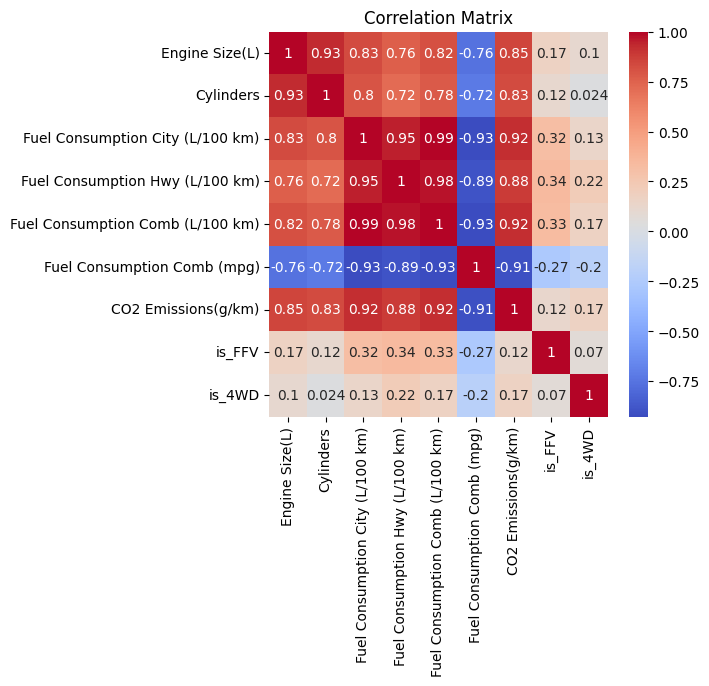



# 9 ) Assess how well the model performs in estimating emissions. Reflect on the meaning of the performance metrics and what they indicate about model reliability.

Train R² Score : 0.9921949021546038
Test R² Score  : 0.9922305402084151
Test MAE       : 3.0346481856606418 g/km
Test RMSE      : 5.197078829585259 g/km



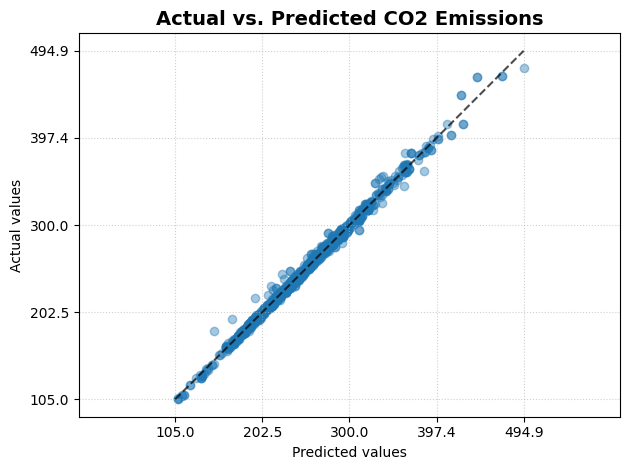

In [65]:
#Get Y_pred
Y_train_pred = full_pipeline.predict(X_train)
Y_test_pred = full_pipeline.predict(X_test)

# Calculate performance metrics
r2_train = r2_score(Y_train, Y_train_pred)
r2_test = r2_score(Y_test, Y_test_pred)
mae_test = mean_absolute_error(Y_test, Y_test_pred)
rmse_test = np.sqrt(mean_squared_error(Y_test, Y_test_pred))

print(f"Train R² Score : {r2_train}")
print(f"Test R² Score  : {r2_test}")
print(f"Test MAE       : {mae_test} g/km")
print(f"Test RMSE      : {rmse_test} g/km")
print("==========================================\n")

from sklearn.metrics import PredictionErrorDisplay
PredictionErrorDisplay.from_predictions(
    y_true=Y_test,
    y_pred=Y_test_pred,
    kind="actual_vs_predicted",
    scatter_kwargs={"alpha": 0.4}
)

plt.title("Actual vs. Predicted CO2 Emissions", fontsize=14, fontweight="bold")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()



###Observations -
**Very high Train and Test R2 score ~99** - our model performed well for both Train and Test data, indicating no underfitting or overfitting is done.
**Test MAE (Mean Absolute Error) is 3.03g/km **— On average, the model's predictions miss the true emissions by almost 3 grams of CO2 per kilometer.

**Actual vs Prediction Plot:** Line fits quite well for mid range(200–380) but both low and high ends is where there is dispersion of points. At low range (110-200) there is some overfitting observed. At high range (>380) overfitting is observed.



In [ ]:
#Get the worst performing vehicles
#This is will fetch all the original details from emission_training_ds_cleaned dataset and add columns for Actual Predicted and Abs_Error
worst_predictions = (
    emission_training_ds_cleaned.loc[Y_test.index]
    .assign(
        Actual_CO2=Y_test,
        Predicted_CO2=Y_test_pred,
        Abs_Error=np.abs(Y_test - Y_test_pred)
    )
    .sort_values(by="Abs_Error", ascending=False)
)

#Get worst 10 predictions
cols = ['Make', 'Vehicle Class', 'Engine Size(L)', 'Fuel Type', 'Fuel Consumption Comb (L/100 km)', 'Actual_CO2', 'Predicted_CO2', 'Abs_Error']
print(worst_predictions[cols].head(10).to_string())

           Make            Vehicle Class  Engine Size(L) Fuel Type  Fuel Consumption Comb (L/100 km)  Actual_CO2  Predicted_CO2  Abs_Error
228   CHEVROLET          VAN - PASSENGER             6.0         E                              25.8         413     460.789565  47.789565
351        FORD          VAN - PASSENGER             5.4         E                              23.9         382     422.480441  40.480441
408        FORD                  COMPACT             2.0         E                              10.1         162     122.089314  39.910686
1488       FORD                  COMPACT             2.0         E                              10.4         166     128.836748  37.163252
476         GMC           SUV - STANDARD             6.2         E                              22.1         354     390.825552  36.825552
2489   CHRYSLER                 MID-SIZE             2.4         E                              11.3         186     149.217920  36.782080
1374   CHRYSLER            

###Observations -
All the worst 10 predictions belongs to Fuel Type - "E" where if we see on high ranges model predicted higher values and on lower end model predicted lesser than actuals. This also explains the above point - *At low range (110-250) there is some overfitting observed. At high range (>300) overfitting is observed.*

So we can conclude that for rest of the Fuel Types , the CO2 emissions follows linear trend but for Ethanol based vehicles , it is not the case. Ethanol based vehicles cause significantly lower emissions than other fuels, but vehicles burn many more liters to cover the same distance.

# 10 ) Based on the analysis and model findings, summarize which factors most strongly influence CO₂ emissions and suggest how such insights could support emission reduction efforts.

##Answer -
# Major Contributors
1.   **Fuel Consumption Comb (L/100 km)**  - The biggest factor in determining the emissions. Because carbon dioxide is a direct chemical byproduct of fuel combustion, every additional liter of fuel consumed per 100 km increases emissions by approximately 65g/km.
2.   **Fuel Type** - Ethanol (Fuel Type E) emit less CO2 per liter than standard gasoline or diesel but vehicles burn higher volumes per kilometer.
3. **Engine Size (L) and Cylinders** - Our model coefficients assigned very low coefficients to these features due to high multicollinearity, they act as the primary physical engines behind high fuel consumption. Large-displacement engines and heavy vehicle classes (such as full-size passenger vans and large SUVs) consistently occupy the highest emission brackets 350–450g/km).



---
# Emission Reduction Suggestions:
**Fuel Efficiency over Engine Size** - Mostly the controls are around Engine Size like higher tax brackets for bigger Engine Size and Body Weights, but if we primarily tax vehicles based of their Fuel Efficiency it will force Manufacturers to work on making the vehicles more fuel efficient resulting in lesser emissions

**Rethink about Ethanol** - Ethanol might look like good alternative and shows good promise to reduce emissions but it also drops efficiency in some vehicles, ultimately increasing the emissions. So a careful adoption of Ethanol in low end vehicles which are not suppose to carry a lot of weight and don't require bigger engines, Ethanol can serve the purpose. But it just wastes more gasoline and carbon in heavy performance vehicles.


**Target Heavy Performance Vehicles** Top-end scatter and highest absolute emissions were heavily concentrated in large commercial vehicles and passenger vans, emission reduction efforts yield the highest marginal impact when targeting these heavy fuel consumers. Commercial fleet electrification or hybridizing high-displacement vans delivers far greater total carbon reduction per vehicle than incrementally tweaking small compact sedans.

